- *Can we identify parallel roles purely from network structure, without narrative context?* SØREN
    * Notes:
        - Node2vec algorithm for finding nodes which are similar in one universe.
        - Struc2vec algorithm for finding nodes across networks which occupy similar structural positions.
        - Maybe: Compute a vector of structural properties (In-degree, Out-degree, Closeness, Eigenvector / pageRank, Clustering coefficient, triadic position, etc.) for each characters, and use clustering algorithms (k-means, hierarchical clustering, Gaussian mixture models)

In [6]:
import numpy as np
import networkx as nx 
import pickle, requests, math
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from gensim.models import KeyedVectors
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter
from util import *

In [7]:
# Load the networks and merge them
with open("hp_characters.pkl", "rb") as f:   # 'rb' = read binary
    HP_data = pickle.load(f)
    
HP_network = create_network(HP_data, field_origin = 'house', field_species = 'species')

with open("lotr_characters.pkl", "rb") as f:   # 'rb' = read binary
    LOTR_data = pickle.load(f)

LOTR_network = create_network(LOTR_data, field_origin = 'culture', field_species = 'race')

G = nx.union(HP_network, LOTR_network)
mapping = {old_label: i + 1 for i, old_label in enumerate(G.nodes())}
G = nx.relabel_nodes(G, mapping)

In [12]:
len(HP_network.nodes())

506

In [92]:
combined_data = {}
for page in HP_data:
    combined_data[page['page_name']] = page['content']
for page in LOTR_data:
    combined_data[page['page_name']] = page['content']

In [93]:
# This was used to generate the edgelist used in the struc2vec implementation.
if False:
    nx.write_edgelist(G, "C:\\Users\\soere\\OneDrive\\Skrivebord\\struc2vec-master\\struc2vec-master\\graph\\graph.edgelist", data=False)
    with open("mapping.pkl", "wb") as f:
        pickle.dump(mapping, f)

In [94]:
# Load the generated embedding
with open("mapping.pkl", "rb") as f:
    mapping = pickle.load(f)
reversed_mapping = {value : item for item, value in mapping.items()}
embeddings = KeyedVectors.load_word2vec_format(f"embedding_128.emb", binary=False)

In [95]:
#download LabTM list

# Direct URL to the raw LabMT file
url = "https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0026752.s001&type=supplementary"

# Download the file
r = requests.get(url)
r.raise_for_status()  # check if download worked
text = r.text

# Split into lines
lines = text.splitlines()

# Skip any lines before the header 
header_index = 0
for i, line in enumerate(lines):
    if line.startswith("word"):
        header_index = i
        break

# Parse the header line
columns = lines[header_index].split('\t')

# Parse the remaining lines into a list of dictionaries
data = []
for line in lines[header_index+1:]:
    values = line.split('\t')
    if len(values) == len(columns):
        data.append(dict(zip(columns, values)))

#  mapping word to happiness_average
word_scores = {row['word']: float(row['happiness_average']) for row in data}


In [96]:
#Define helper functions
def calculate_sentiment(tokens, word_scores):
    valid_scores = [word_scores[w] for w in tokens if w in word_scores]
    if not valid_scores:
        return np.nan
    return np.mean(valid_scores)

def sentiment(G, data = combined_data, mapping = reversed_mapping, word_scores = word_scores):
    sentiments = []
    for node in G.nodes():
        tokens = word_tokenize(data[mapping[node]])
        tokens = [t.lower() for t in tokens if t.isalpha()]
        sentiments.append((node, calculate_sentiment(tokens, word_scores)))

    return sentiments

def select_best_gmm_k(X, k_min=2, k_max=30):
    bic_scores = []
    gmms = []
    
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            random_state=42
        )
        gmm.fit(X)
        bic = gmm.bic(X)
        bic_scores.append(bic)
        gmms.append(gmm)

    best_idx = np.argmin(bic_scores)
    best_k = k_min + best_idx
    best_gmm = gmms[best_idx]
    
    print(f"Best number of clusters (BIC): {best_k}")
    return best_k, best_gmm, bic_scores

def get_ordering(ordering):
    if isinstance(ordering, dict):
        return np.array([snd for _, snd in sorted([(node, deg) for node, deg in ordering.items()], key = lambda x: x[0] )])
    else:
        return np.array([snd for _, snd in sorted([(node, deg) for node, deg in ordering], key = lambda x: x[0] )])

def construct_X(G, embedding):
    in_deg = get_ordering(G.in_degree())
    out_deg = get_ordering(G.out_degree())
    closesness = get_ordering(nx.closeness_centrality(G)) 
    betweenness = get_ordering(nx.betweenness_centrality(G))
    pagerank = get_ordering(nx.pagerank(G))  
    clustering = get_ordering(nx.clustering(G))  
    sentiment_ = get_ordering(sentiment(G))

    word_vectors = []

    for key in embedding.index_to_key:
        word_vectors.append((int(key), embedding[key]))

    word_vectors = sorted(word_vectors, key = lambda x: x[0])

    word_vectors = np.array([snd for _, snd in word_vectors])

    X = np.c_[np.array([in_deg, out_deg, closesness, betweenness, pagerank, clustering, sentiment_]).T, word_vectors]
    return X

def plot_pca_first_two(Z, labels):
    pca = PCA(n_components=2)
    Z_pca = pca.fit_transform(Z)

    labels = np.array(labels)

    unique_labels = np.unique(labels)

    plt.figure(figsize=(7, 7))

    for lab in unique_labels:
        idx = labels == lab
        plt.scatter(
            Z_pca[idx, 0],
            Z_pca[idx, 1],
            label=str(lab)
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA (first two components)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return Z_pca


The shape of X is : (1383, 135)
Best number of clusters (BIC): 5


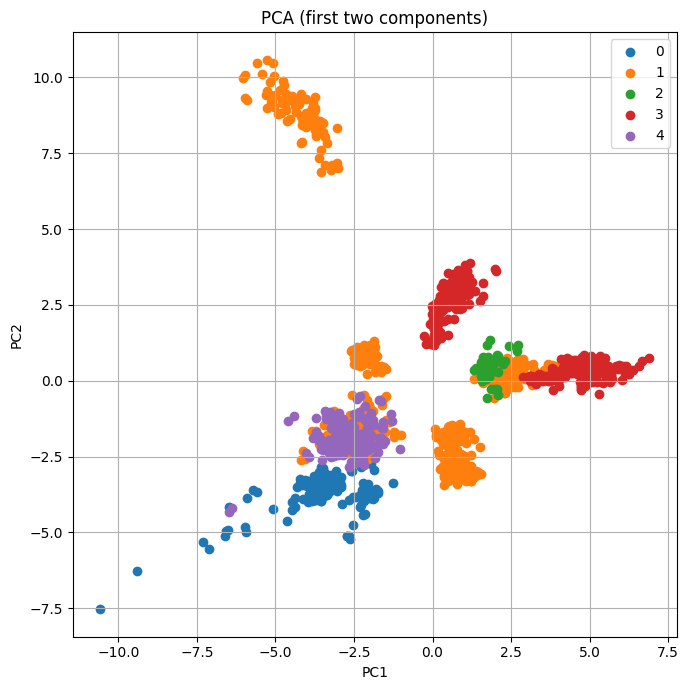

In [97]:
# Construct and normalize the data
X = construct_X(G, embeddings)
print(f'The shape of X is : {X.shape}')
Z = (X - np.mean(X, axis = 0)) / np.std(X, axis = 0)

# Select and train the best suited GMM
best_k, best_gmm, bic_scores = select_best_gmm_k(Z)

result = best_gmm.fit_predict(Z)

groups = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    groups[x] = {'Names' : lst, 'index' : idx}

partition = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    partition[x] = lst

Z_pca = plot_pca_first_two(Z, result)

In [98]:
# Declare helper functions
def create_corpus(wikipedia_data, partition, filter_n = 5):
    corpus = {}
    if isinstance(partition, dict):
        for key, nodes in partition.items():
            corpus[key] = ''
            for node in nodes:
                    corpus[key] += wikipedia_data[node]

    elif isinstance(partition, list):
        for i, nodes in enumerate(partition):
            key = f'Community {i+1}'
            corpus[key] = ''
            for node in nodes:
                corpus[key] += wikipedia_data[node]

    lemmatizer = WordNetLemmatizer()
    for key, item in corpus.items():
        tokens = word_tokenize(item)
        tokens = [word for word in tokens if word.isalnum()]
        tokens = [word.lower() for word in tokens]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        word_counts = Counter(tokens)
        tokens = [word for word in tokens if word_counts[word] >= filter_n]
        token_counts = {word: count for word, count in word_counts.items() if count >= filter_n}
        token_counts = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
        corpus[key] = token_counts
    return corpus

def TF_IDF(corpus):
    corpus = corpus.copy()
    total_number_of_documents = len(corpus)
    word_list = {}
    for key, document in corpus.items():
        for word, amount in document:
            if word not in word_list:
                word_list[word] = 1
            else:
                word_list[word] += 1
    
    for key, document in corpus.items():
        total_number_of_words = sum([amount for _, amount in document])
        new_document = []
        for word, amount in document:
            TF = amount / total_number_of_words
            IDF = np.log(total_number_of_documents / word_list[word])
            new_document.append((word, amount, TF, IDF, TF * IDF))
            
        corpus[key] = sorted(new_document, key = lambda x: x[4], reverse=True)
    
    return corpus

def create_wordclouds(corpus, width = 400, height = 300):

    def normalize(x, a, b):
            return (x-b)/(a-b) * 1000
    n = len(corpus)
    if n == 0:
        print("Corpus is empty.")
        return

    # --- Figure layout ---
    rows = 2  # number of columns in the grid
    cols = math.ceil(n / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 8))
    axes = axes.flatten() if n > 1 else [axes]

    # --- Create word clouds for each community ---
    for i, (key, token_counts) in enumerate(corpus.items()):
        # Convert list of tuples into a frequency dictionary
        TF_IDF_list = [TF_IDF for _,_,_,_,TF_IDF in token_counts]
        max_, min_ = max(TF_IDF_list), min(TF_IDF_list)
        
        freq_dict = []
        for word, _, _, _, TF_IDF in token_counts:
            freq_dict.append((word, normalize(TF_IDF, max_, min_)))
        freq_dict = dict(freq_dict)
        if not freq_dict:
            axes[i].set_visible(False)
            continue

        wc = WordCloud(
            width=width,
            height=height,
            background_color='white',
            colormap='viridis',
            random_state=42
        ).generate_from_frequencies(freq_dict)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(key, fontsize=16)
        axes[i].axis('off')

    # --- Hide any unused subplots ---
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def get_X_most_common_words(corpus, X = 10):
    for key, item in corpus.items():
        top_x = [word for word, _, _, _, _ in item[:X]]
        print(f'Group {key}: {top_x}')



In [99]:
corpus = create_corpus(combined_data, partition)
c2 = TF_IDF(corpus)
get_X_most_common_words(c2)


Group 0: ['ginny', 'bellatrix', 'ron', 'snape', 'charlie', 'barty', 'riddle', 'radagast', 'horcrux', 'grindelwald']
Group 1: ['ernie', 'baron', 'amata', 'conjecture', 'natsai', 'fig', 'stan', 'luckless', 'berúthiel', 'orgol']
Group 2: ['amos', 'tulip', 'kettleburn', 'verucca', 'goatleaf', 'ferny', 'silvanus', 'lurtz', 'oikeroi', 'araphor']
Group 3: ['babbitty', 'conjecture', 'charlatan', 'oakes', 'budge', 'helga', 'kal', 'bolger', 'fram', 'lobelia']
Group 4: ['crabbe', 'narcissa', 'kreacher', 'andromeda', 'rakepick', 'ben', 'ted', 'goyle', 'bellatrix', 'uin']


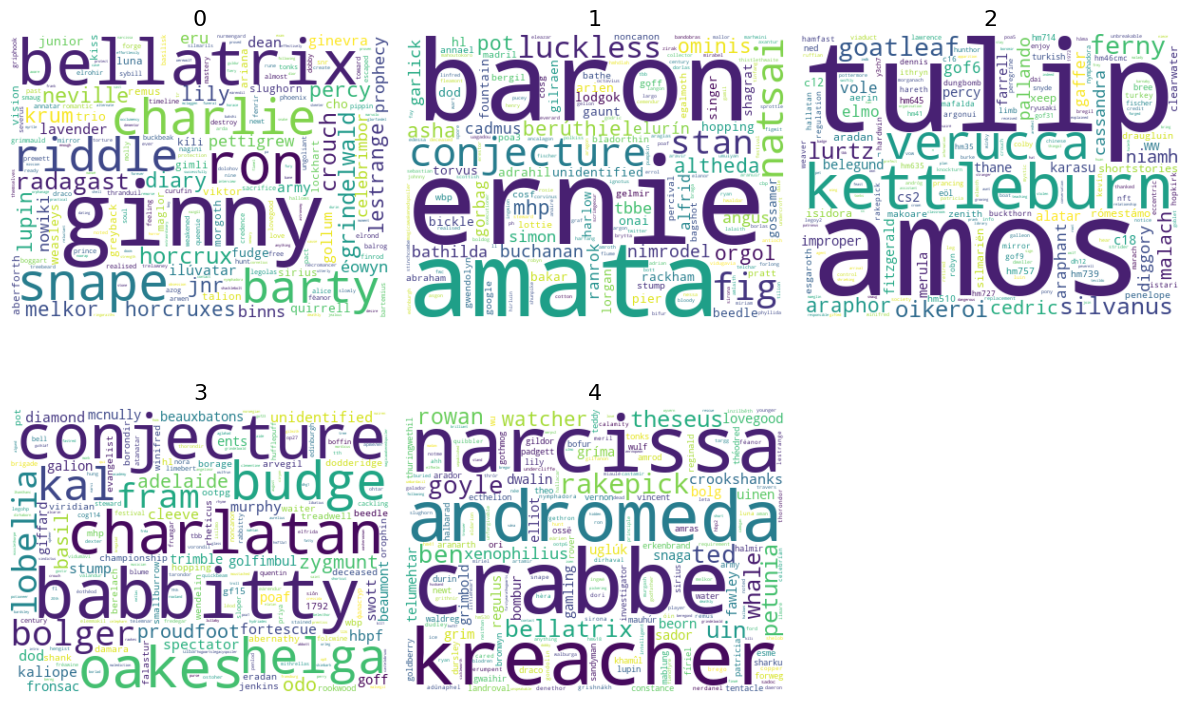

In [100]:
create_wordclouds(c2)

In [101]:
def create_x_y(G):
    sent = sentiment(G)
    x, y = [], []
    for node, sentiment_score in sent:
        y.append(sentiment_score)
        x.append(len(combined_data[reversed_mapping[node]].split(' ')))
    
    return x, y

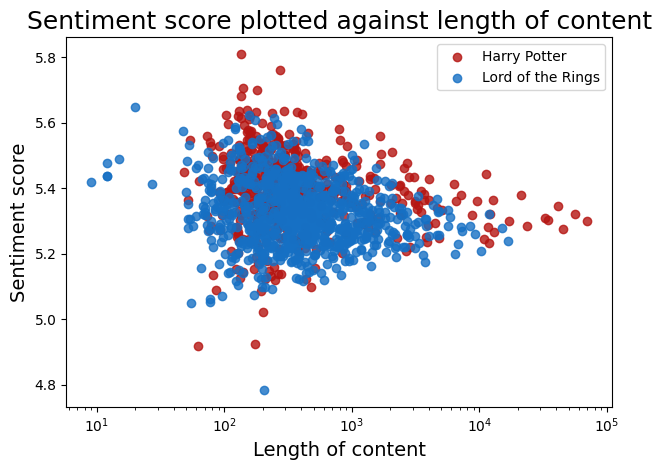

In [102]:
x,y = create_x_y(nx.relabel_nodes(HP_network, mapping))
plt.scatter(x,y, label = 'Harry Potter', alpha = 0.8, c= '#b51512')
x,y = create_x_y(nx.relabel_nodes(LOTR_network, mapping))
plt.scatter(x,y, label = 'Lord of the Rings', alpha = 0.8, c= '#1670c4')
plt.xlabel('Length of content', fontsize = 14)
plt.ylabel('Sentiment score', fontsize = 14)
plt.title('Sentiment score plotted against length of content', fontsize = 18)
plt.legend()
plt.xscale('log')
plt.tight_layout()

In [103]:
sent = sentiment(G)

metrics = {key : {'sentiment' : [], 'length of content' : [], 'degree' : []} for key in partition.keys()}
degrees = G.degree()
for node_int, sentiment_score in sent:
    real_name = reversed_mapping[node_int]
    for key, item in partition.items():
        if real_name in item:
            metrics[key]['sentiment'].append(sentiment_score)
            metrics[key]['length of content'].append(len(combined_data[real_name].split(' ')))
            metrics[key]['degree'].append(degrees[node_int])


In [104]:
top = 5

for key, item in partition.items():
    group = key 
    characters = item
    char2int = [mapping[c] for c in characters]
    degrees     = [node for node, _ in sorted([(c, d) for c,d in G.degree() if c in char2int], key = lambda x: x[1], reverse = True)][:top]
    betweenness = [node for node, _ in sorted([(c,d) for c,d in nx.betweenness_centrality(G).items() if c in char2int], key = lambda x: x[1], reverse = True)][:top]
    words       = [node for node, _ in sorted([(node, data['words']) for node, data in G.nodes(data=True) if node in char2int], key = lambda x: x[1], reverse = True)][:top]

    item = metrics[key]
    print('#'*150)
    print(f'{f'Group {key}':<10} {f'Members: {len(item['sentiment'])}':>30}, {f'Average: sentiment {np.mean(item['sentiment']):.2f}':>30}, {f'Average words: {np.mean(item['length of content']):.2f}':>30}, {f'Average degree: {np.mean(item['degree']):.2f}':>30}')
    print()
    print(f'{"Rank":<5} {"Degree centrality":>40} {"Betweenness centrality":>40} {'Length of content':>40}')
    print('-' * 140)
    for i in range(len(degrees)):
        print(f'{i+1:<5} {reversed_mapping[degrees[i]]:>40} {reversed_mapping[betweenness[i]]:>40} {reversed_mapping[words[i]]:>40}')
    print('-' * 140)
    print()
    print('#'*150)
    print()


######################################################################################################################################################
Group 0                      Members: 127,        Average: sentiment 5.30,         Average words: 5808.45,          Average degree: 57.47

Rank                         Degree centrality                   Betweenness centrality                        Length of content
--------------------------------------------------------------------------------------------------------------------------------------------
1                                 Harry_Potter                                   Sauron                             Harry_Potter
2                                       Sauron                               Aragorn_II                         Albus_Dumbledore
3                                      Gandalf                                  Morgoth                               Tom_Riddle
4                                      Morgoth       